In [1]:
import pandas as pd

add chart title and axis labels to increase understanding

In [2]:
transactions = pd.read_csv("../retailFiles/transactions.csv")
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


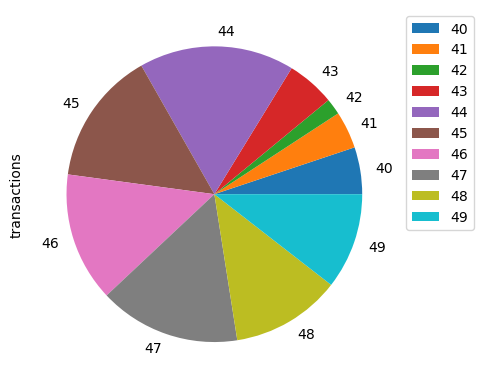

In [7]:
store_40s = list(range(40, 50))
(transactions
 .query("store_nbr in @store_40s and date.astype('datetime64[ns]').dt.month in [1, 2, 3]")
 .groupby("store_nbr")
 .agg({"transactions": "sum"})
 .plot.pie(y="transactions")
).legend(bbox_to_anchor=(1, 1))

In [12]:
(
    transactions
    .query("store_nbr in @store_40s")
    .pivot_table(
                index=transactions["date"].astype("datetime64[ns]").dt.month,
                columns="store_nbr",
                values="transactions",
                aggfunc="sum"
                )
)

store_nbr,40,41,42,43,44,45,46,47,48,49
date,,,,,,,,,,
1,185490,148431,64758,188657,628438,538370,522763,568824,439045,386589
2,179215,143437,62400,186951,584046,511411,493100,539453,422158,362406
3,199810,156254,67713,203827,655630,561184,540294,594248,460341,407071
4,194785,152869,66870,195502,637139,549474,535584,586216,454378,402373
5,208281,166079,69883,202376,671126,570956,554270,597380,469508,421413
6,196988,155688,67692,190156,631016,541302,516034,562559,436015,401579
7,203107,161205,70549,201074,645571,563700,531886,577574,454707,407053
8,182747,146306,63371,182532,596279,514143,485675,524983,419362,365448
9,151905,119653,64763,146055,516233,422178,412455,455021,353820,317871


<Axes: xlabel='44', ylabel='47'>

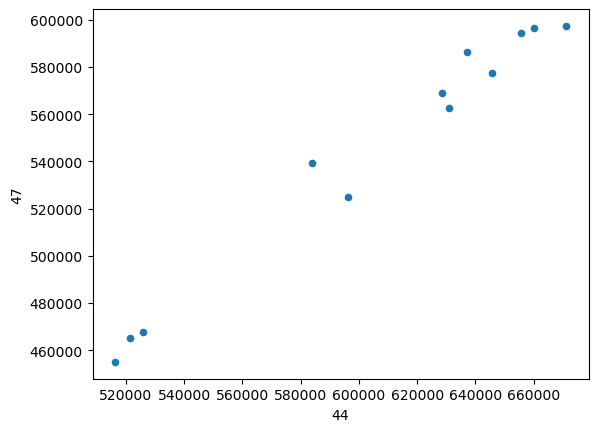

In [11]:
(
    transactions
    .query("store_nbr in @store_40s")
    .pivot_table(
                index=transactions["date"].astype("datetime64[ns]").dt.month,
                columns="store_nbr",
                values="transactions",
                aggfunc="sum"
                )
    .plot.scatter(x=44, y=47)
)